## Load Data testing

In [19]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

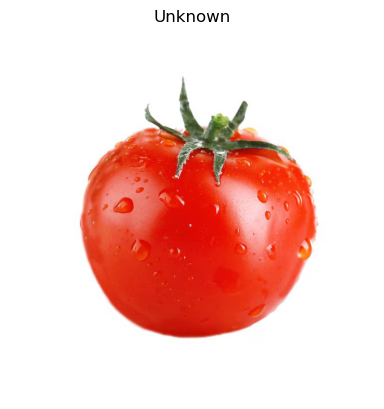

In [20]:
test_img = cv2.imread('tomat.avif')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_label = 'Unknown'
plt.imshow(test_img)
plt.title(test_label)
plt.axis('off')
plt.show()

In [21]:
img_list = [[test_img, test_label]]

## Prepocessing

In [22]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

In [23]:
def segment_object_hsv(img):
    """Segmentasi menggunakan HSV color space"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Buat mask untuk objek non-hitam/putih
    lower = np.array([0, 30, 30])  # Hindari warna gelap
    upper = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    
    # # Morphological operations untuk membersihkan noise
    # kernel = np.ones((5,5), np.uint8)
    # mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    # mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Cari contour terbesar (asumsi objek adalah area terbesar)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask_final = np.zeros_like(mask)
        cv2.drawContours(mask_final, [largest_contour], -1, 255, -1)
    else:
        mask_final = mask
    
    # Apply mask
    mask3 = np.repeat(mask_final[..., None], 3, axis=2).astype("uint8") // 255
    masked_bgr = img * mask3
    masked_rgb = cv2.cvtColor(masked_bgr, cv2.COLOR_BGR2RGB)
    
    return masked_rgb

In [24]:
def preprocessing_basic(img_list):
    result = []
    for img, label in img_list:
        
        resized = cv2.resize(img, (224, 224))
        clahe = apply_clahe(resized)
        seg_mask = segment_object_hsv(clahe)   

        final_img = clahe * (seg_mask > 0)

        result.append((final_img, label))
    
    return result


In [25]:
def preprocess_for_HSV(processed_list):
    result = []
    for img, label in processed_list:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        result.append((hsv, label))
    return result

In [26]:
def preprocess_for_GLCM(processed_list):
    result = []
    for img, label in processed_list:
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result.append((grey, label))
    return result

## Ekstraksi fitur

In [27]:
from scipy.stats import skew, kurtosis, entropy

def extract_HSV_hist(img_list, bins=(8, 8, 8)):
    features = []
    
    for img, label in img_list:
        img_hsv = img
        
        img_features = []
        
        # Loop kanal warna
        for i in range(3):  # 0=H,1=S,2=V
            channel = img_hsv[:,:,i].ravel()

            mean_val = np.mean(channel)
            std_val = np.std(channel)
            var_val = np.var(channel)
            skew_val = skew(channel)
            kurt_val = kurtosis(channel)
            entr = entropy(np.histogram(channel, bins=256)[0] + 1e-7)

            img_features.extend([mean_val, std_val, var_val, skew_val, kurt_val, entr])
        
        features.append((np.array(img_features), label))
    
    return features

In [28]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

def extract_GLCM(img_list):
    features = []

    distances = [1, 2]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    for img, label in img_list:
        glcm = graycomatrix(img, distances=distances, angles=angles, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()

        glcm_feat = np.hstack([contrast, homogeneity, energy, correlation])
        features.append((glcm_feat, label))

    return features

## Load Model

In [29]:
import joblib
svm_model_color = joblib.load('svm_color.joblib')
knn_model_color = joblib.load('knn_color.joblib')
rf_model_color  = joblib.load('rf_color.joblib')

In [30]:
svm_model_glcm = joblib.load('svm_glcm.joblib')
knn_model_glcm = joblib.load('knn_glcm.joblib')
rf_model_glcm  = joblib.load('rf_glcm.joblib')

## Test Color

In [31]:
val_features = []
val_filenames = []

for img, filename in img_list:
    
    # preprocessing umum
    basic = preprocessing_basic([(img, "unknown")])
    
    hsv_img  = preprocess_for_HSV(basic)


    hsv_f  = extract_HSV_hist(hsv_img)[0][0]

    combined = np.hstack([hsv_f])

    val_features.append(combined)
    val_filenames.append(filename)

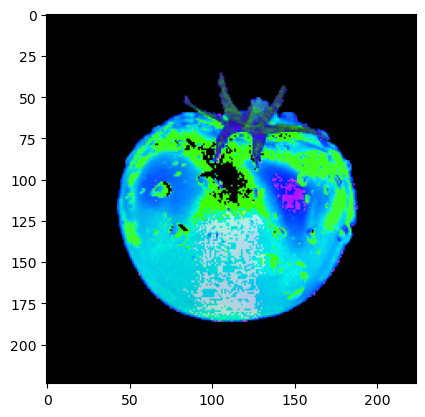

In [40]:
plt.imshow(hsv_img[0][0])

In [32]:
scaler_color = joblib.load('scaler_color.joblib')
val_scaled = scaler_color.transform(val_features)

In [33]:
svm_color_preds = svm_model_color.predict(val_scaled)
knn_color_preds = knn_model_color.predict(val_scaled)
rf_color_preds  = rf_model_color.predict(val_scaled)

In [34]:
label_encoder = joblib.load('label_encoder.joblib')
svm_color_labels = label_encoder.inverse_transform(svm_color_preds)
knn_color_labels = label_encoder.inverse_transform(knn_color_preds)
rf_color_labels  = label_encoder.inverse_transform(rf_color_preds)
for i, filename in enumerate(val_filenames):
    print(f"Image: {filename}")
    print(f" SVM Prediction: {svm_color_labels[i]}")
    print(f" KNN Prediction: {knn_color_labels[i]}")
    print(f" RF Prediction: {rf_color_labels[i]}")
    print()

Image: Unknown
 SVM Prediction: Sayur Daun
 KNN Prediction: Sayur Daun
 RF Prediction: Sayur Daun



## Test GLCM

In [35]:
val_features = []
val_filenames = []

for img, filename in img_list:
    
    # preprocessing umum
    basic = preprocessing_basic([(img, "unknown")])
    
    glcm_img = preprocess_for_GLCM(basic)

    glcm_f = extract_GLCM(glcm_img)[0][0]
    
    combined = np.hstack([glcm_f])

    val_features.append(combined)
    val_filenames.append(filename)

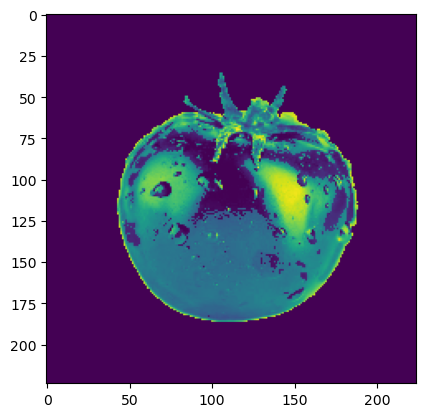

In [41]:
plt.imshow(glcm_img[0][0])

In [36]:
scaler_glcm = joblib.load('scaler_glcm.pkl')
val_scaled = scaler_glcm.transform(val_features)

In [37]:
svm_glcm_preds = svm_model_glcm.predict(val_scaled)
knn_glcm_preds = knn_model_glcm.predict(val_scaled)
rf_glcm_preds  = rf_model_glcm.predict(val_scaled)

In [38]:
svM_glcm_labels = label_encoder.inverse_transform(svm_glcm_preds)
knN_glcm_labels = label_encoder.inverse_transform(knn_glcm_preds)
rf_glcm_labels  = label_encoder.inverse_transform(rf_glcm_preds)
for i, filename in enumerate(val_filenames):
    print(f"Image: {filename}")
    print(f" SVM GLCM Prediction: {svM_glcm_labels[i]}")
    print(f" KNN GLCM Prediction: {knN_glcm_labels[i]}")
    print(f" RF GLCM Prediction: {rf_glcm_labels[i]}")
    print()

Image: Unknown
 SVM GLCM Prediction: Sayur Daun
 KNN GLCM Prediction: Sayur Daun
 RF GLCM Prediction: Sayur Daun

